Dataset shape: (1385, 6)
Columns: ['Disease_name', 'miRNA', 'sequence', 'genes', 'label', 'context']

Missing values:
Disease_name    0
miRNA           0
sequence        0
genes           0
label           0
context         0
dtype: int64


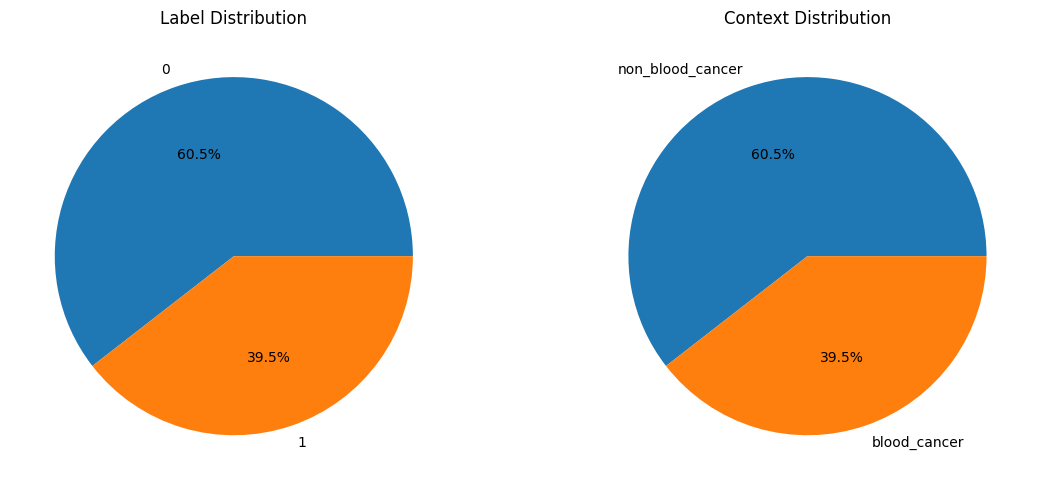

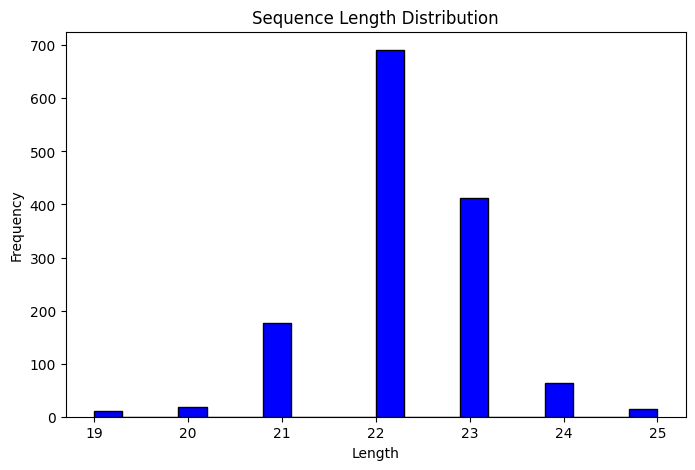

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os

def explore_dataset(input_file, output_folder="figures"):
    # Folder তৈরি যদি না থাকে
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    df = pd.read_csv(input_file)
    df.columns = df.columns.str.strip()

    print("Dataset shape:", df.shape)
    print("Columns:", df.columns.tolist())

    print("\nMissing values:")
    print(df.isnull().sum())

    # Label distribution
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.pie(df['label'].value_counts(),
            labels=df['label'].value_counts().index,
            autopct='%1.1f%%')
    plt.title("Label Distribution")

    plt.subplot(1, 2, 2)
    plt.pie(df['context'].value_counts(),
            labels=df['context'].value_counts().index,
            autopct='%1.1f%%')
    plt.title("Context Distribution")

    plt.tight_layout()
    # Save figure
    plt.savefig(os.path.join(output_folder, "label_context_distribution.png"))
    plt.show()

    # Sequence length
    df['seq_length'] = df['sequence'].astype(str).str.len()
    plt.figure(figsize=(8, 5))
    plt.hist(df['seq_length'], bins=20, color='blue', edgecolor='black')
    plt.title("Sequence Length Distribution")
    plt.xlabel("Length")
    plt.ylabel("Frequency")
    # Save figure
    plt.savefig(os.path.join(output_folder, "sequence_length_distribution.png"))
    plt.show()

if __name__ == "__main__":
    explore_dataset("New Dataset.csv")